# OPS-SAT 1 Re-entry UHF Telemetry Analysis

## 1. Introduction

OPS-SAT is a 3U CubeSat launched by the European Space Agency (ESA) on December 18, 2019. Designed to be an in-orbit laboratory for software experiments, the mission control team kept it active until its re-entry at around 22:30 UTC on 22 May 2024.  
In this context, the amateur radio community was mobilized through a public platform and the [gr-opssat software](https://github.com/esa/gr-opssat/tree/master), and the [SatNogs network](https://satnogs.org/). The aim was to collect as many UHF packets as possible, broadcast by the satellite, and monitoring onboard telemetry. Thanks to the community we are now able to provide a [dataset](http://link-to-the-dataset) of the telemetry from the *2024-05-01* to the *2024-05-22*, date of the re-entry.  

In this notebook, we offer a quick review of the available data, and possible approaches to their analysis.

### Prerequisites

In [1]:
!pip install pandas numpy matplotlib h3pandas geopandas skyfield pytz geodataset folium

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## 2. TLEs Analysis

In order to corellate some data with the OPS-SAT 1 flight trajectory, we need in the first place to have and process TLEs from the same period. As will be described later, the increase in drag implies a reduced validity time for trajectory propagation. Hence, a file with TLEs from space-track.org during the re-entry is provided.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from skyfield.api import load, EarthSatellite, wgs84
import time
import pytz
import h3pandas
import geopandas as gpd
import geodatasets
import folium

pd.set_option('display.max_columns', None)

# Read OPS-SAT TLEs from file
with open('tle_opssat.txt', 'r') as file:
    ops_sat_tle_history = file.readlines()

Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'geodatasets'

### 2.1. Altitude Visualisation

As an example of TLE processing, let's plot the altitude evolution of OPS-SAT 1

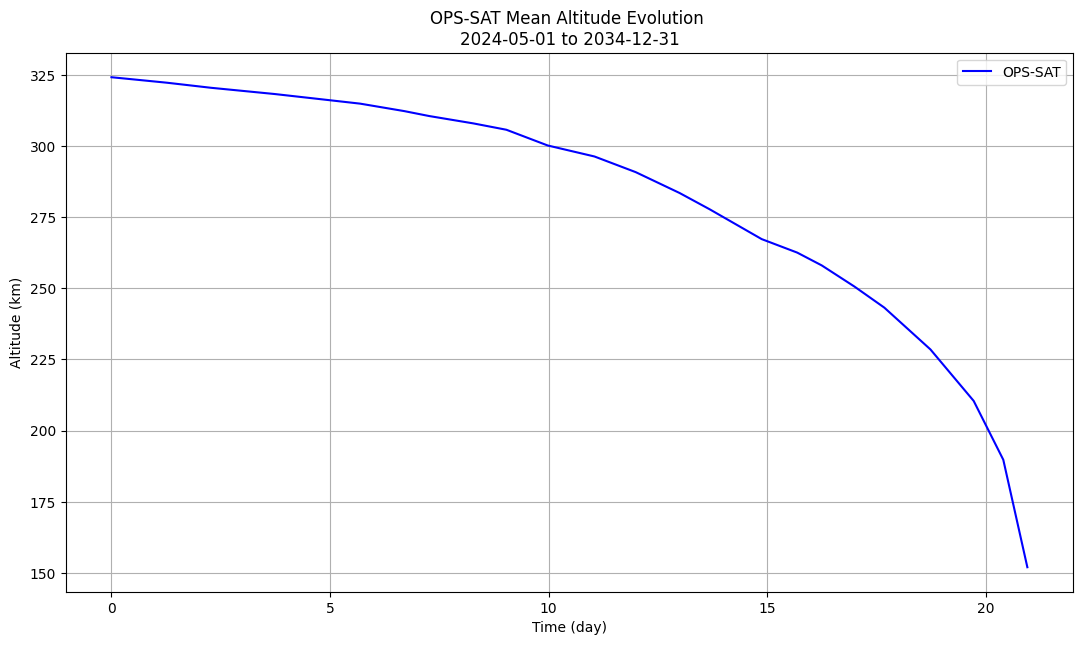

In [2]:
def calculate_altitude(tle):
    # Parse TLE lines with Skyfield
    satellite = EarthSatellite(tle[0], tle[1], 'OPS-SAT', load.timescale())
    orbit = satellite.model
    semi_major_axis = orbit.a # Semi-major axis in km
    earth_equatorial_radius = 6378.137 # in km (WGS84 standard)
    altitude = (semi_major_axis - 1) * earth_equatorial_radius
    return satellite.epoch.utc_datetime(), altitude

# Calculate orbit altitude for OPS-SAT
ops_sat_altitude_history = []
# Ensure there are enough lines for TLE (name, line1, line2)
for tle_index in range(0, len(ops_sat_tle_history) - 2, 3):
    tle_lines = [ops_sat_tle_history[tle_index + 1].strip(), ops_sat_tle_history[tle_index + 2].strip()]
    timestamp, altitude = calculate_altitude(tle_lines)
    ops_sat_altitude_history.append((timestamp, altitude))

# Sort OPS-SAT altitude history based on timestamp
ops_sat_altitude_history.sort(key=lambda x: x[0])

# Extract timestamps and altitudes for OPS-SAT plotting
ops_sat_start_date = ops_sat_altitude_history[0][0]
ops_sat_end_date = ops_sat_altitude_history[-1][0]
ops_sat_timestamps = [(timestamp - ops_sat_start_date).total_seconds() / (24 * 3600) for timestamp, _ in ops_sat_altitude_history]
ops_sat_altitudes = [altitude for _, altitude in ops_sat_altitude_history]

# Plot altitude evolution for OPS-SAT
plt.figure(figsize=(13, 7))
plt.plot(ops_sat_timestamps, ops_sat_altitudes, color='blue', label='OPS-SAT')
plt.xlabel('Time (day)')
plt.ylabel('Altitude (km)')
plt.title(f'OPS-SAT Mean Altitude Evolution \n{ops_sat_start_date.strftime("%Y-%m-%d")} to {ops_sat_end_date.strftime("%Y-%m-%d")}')
plt.legend()  # Show legend
plt.grid(True)
plt.show()

### 2.2 Orbit Parameters

Now, let's build a dataframe with the usefull parameters we can get from propagating each TLEs.  
We will use this dataframe to store the timestamp, the altitude and the B* drag coefficient.

In [3]:
def extract_timestamp(tle):
    # Extract date from the first line of the TLE
    epoch_year = int(tle[0][18:20])  # Extract year
    epoch_day = float(tle[0][20:32])  # Extract day with fractional days
    timestamp = datetime(year=2000 + epoch_year, month=1, day=1) + timedelta(days=epoch_day - 1)
    return timestamp

ops_sat_tle_history_with_timestamp = []
for tle_index in range(0, len(ops_sat_tle_history), 2):
    tle_lines = [ops_sat_tle_history[tle_index].strip(), ops_sat_tle_history[tle_index + 1].strip()]
    timestamp = extract_timestamp(tle_lines)
    ops_sat_tle_history_with_timestamp.append((timestamp, tle_lines[0], tle_lines[1]))

df_tle = pd.DataFrame(ops_sat_tle_history_with_timestamp, columns=['timestamp', 'tle_line1', 'tle_line2'])

df_tle = df_tle.drop_duplicates(subset=['timestamp'], keep='first').reset_index(drop=True)
df_tle = df_tle.sort_values(by='timestamp').reset_index(drop=True)
df_tle.set_index('timestamp', inplace=True)
# df_tle.index = df_tle.to_datetime(df.index)

display(df_tle.head())

,tle_line1,tle_line2
timestamp,,
2024-05-01 01:39:26.766720,1 44878U 19092F 24122.06905980 .00242646 0...,2 44878 97.4411 326.1064 0000465 216.2541 143...
2024-05-01 06:12:54.576000,1 44878U 19092F 24122.25896500 .00263568 0...,2 44878 97.4410 326.3115 0000554 220.1420 139...
2024-05-01 19:53:11.994720,1 44878U 19092F 24122.82861105 .00254499 0...,2 44878 97.4410 326.9276 0000490 231.4465 128...
2024-05-02 01:57:43.794432,1 44878U 19092F 24123.08175688 .00234744 0...,2 44878 97.4407 327.2014 0000505 230.6787 129...
2024-05-02 12:35:35.537568,1 44878U 19092F 24123.52471687 .00236712 0...,2 44878 97.4409 327.6806 0000593 230.4374 129...


---
## 3. Load the OPS-SAT 1 Telemetry Dataset

Now, we are going to load the `uhf_telemetry.csv` file, which is our dataset, as a pandas dataframe.  

### 3.1. Description
The dataset has the following columns:


| Column Name                 | Description                                                                          |
|-----------------------------|--------------------------------------------------------------------------------------|
| Timestamp                   | time of reception of the data                                                        |
| ADCS_mode                   | Configuration of ADCS mode                                                           |
| X_Coarse_Spin               | Gyroscope measurement of satellite angular momentum for X axis (rad/s)               |
| Y_Coarse_Spin               | Gyroscope measurement of satellite angular momentum for Y axis (rad/s)               |
| Z_Coarse_Spin               | Gyroscope measurement of satellite angular momentum for Z axis (rad/s)               |
| PD1_CSS_theta               | Coarse sun sensor value for PD1 (rad)                                                |
| PD2_CSS_theta               | Coarse sun sensor value for PD2 (rad)                                                |
| PD3_CSS_theta               | Coarse sun sensor value for PD3 (rad)                                                |
| PD4_CSS_theta               | Coarse sun sensor value for PD4 (rad)                                                |
| PD5_CSS_theta               | Coarse sun sensor value for PD5 (rad)                                                |
| PD6_CSS_theta               | Coarse sun sensor value for PD6 (rad)                                                |
| HD_Cam_Temp                 | Temperature value of HD Camera (degC)                                                |
| NanoCom_Temp                | NanoCom temperature (to convert to degC)                                             |
| ACU2_Temp                   | NanoPower P60 temperature of the Array Conditioning Unit n°2                         |
| Battery_Temp                | Battery temperature                                                                  |
| Battery_Voltage             | Battery voltage                                                                      |
| NanoMind_Temp               | NanoMind temperature                                                                 |
| PDU_Channels_Status         | 0,0,0,Cam,GPS,Opt,iADCS,SDR,Xband,Ncom,Sband,CCSDS,SEPP2,SEPP1,NM1,NM2               |
| SDR_Temp                    | SDR temperature                                                                      |
| SEPP_Temp                   | SEPP temperature                                                                     |
| Background_RSSI             | beacon - AX100 transceiver telemetry - Background Received Signal Strength Indicator |
| Last_RSSI                   | beacon - AX100 transceiver telemetry - Last received RSSI                            |
| NanoCom_Temp                | beacon - AX100 transceiver telemetry - Board temperature [Same as COM8954p]          |

Additional lines added by the following scripts:
| Column Name                 | Description                                                                          |
|-----------------------------|--------------------------------------------------------------------------------------|
| Days_Elapsed                | Time elapsed (in days) since the first UHF packet [2024-05-01 04:57]                 |
| Altitude                    | Altitude of the spacecraft, calculated by TLE propagation                            |
| Bstar_drag                  | B* drag coefficient, calculated by TLE propagation                                   |
| lat                         | Latitude                                                                             |
| lng                         | Longitude                                                                            |

### 3.2. Payload Overview

 - **NanoMind**  
The NanoMind is the main computer of the satellite, which act as a supervisor of the satellite.
 - **NanoCom**  
Also refered as AX100 transceiver, is used for UHF communication and direct communication with the NanoMind. The frames used for this dataset were emitted by the NanoCom.  
The beacon is a specific type of UHF frames that contains informations related to the NanoCom itself.
 - **SEPP**  
The Satellite Experimental Processing Platform (SEPP) is the heart of the OPS-SAT. It is a powerful ALTERA Cyclone V system-on-chip (SoC) module with sufficient on-board memory to carry out advanced software and hardware experiments. The device provides powerful processing capability with an 800MHz CPU clock and 1GB DDR3 RAM. It is the reconfigurable platform required on OPS-SAT on which all major experiments are processed.
 - **SDR**  
The Software Define Radio is an onboard device that can be configured to capture the signal at a chosen frequency, gain, and sampling rate
 - **ADCS**  
The Attitude Determination and Control System (ADCS) consists of multiple devices (reaction wheels, star trackers, magnetorquers, etc.) that allow the satellite to understand the evolution of its position in space, mostly its spin rate in the case of OPS-SAT 1. It has a fine ADCS used for precision pointing during experiments and a coarse ADCS linked to the NanoMind, which is always available to maintain pointing and prevent an increase in the spin rate.  
The row ADCS_mode refers to the coarse ADCS.

In [4]:
# Load the CSV file into a Pandas DataFrame
df_telemetry = pd.read_csv('uhf_telemetry.csv')

df_telemetry['Timestamp'] = pd.to_datetime(df_telemetry['Timestamp'])
df_telemetry.set_index('Timestamp', inplace=True)
df_telemetry.sort_index(inplace=True)

# New columns which counts down the time elapsed (in days) since the first UHF packet [2024-05-01 04:57]
df_telemetry['Days_Elapsed'] = (df_telemetry.index - df_telemetry.index.min()).total_seconds() / (24 * 3600)

df_telemetry['SEPP_Temp'] = df_telemetry['SEPP_Temp'] * 10
df_telemetry['SDR_Temp'] = df_telemetry['SDR_Temp'] * 10

df_telemetry['PDU_Channels_Status'] = pd.to_numeric(df_telemetry['PDU_Channels_Status'], errors='coerce').astype('Int64')

# Convert the integer value of PDU_Channels_Status into a string of binary
df_telemetry['PDU_Channels_Status'] = df_telemetry['PDU_Channels_Status'].apply(
    lambda x: f'{int(x):016b}' if pd.notna(x) else np.nan
)


display(df_telemetry)

,ADCS_mode,X_Coarse_Spin,Y_Coarse_Spin,Z_Coarse_Spin,PD1_CSS_theta,PD2_CSS_theta,PD3_CSS_theta,PD4_CSS_theta,PD5_CSS_theta,PD6_CSS_theta,HD_Cam_Temp,ACU2_Temp,Battery_Temp,Battery_Voltage,NanoMind_Temp,PDU_Channels_Status,SDR_Temp,SEPP_Temp,Background_RSSI,Last_RSSI,NanoCom_Temp,Days_Elapsed
Timestamp,,,,,,,,,,,,,,,,,,,,,,
2024-05-01 04:57:03.720,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0001001001111101,NaN,NaN,NaN,NaN,NaN,0.000000
2024-05-01 04:57:10.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-111.0,0.0,434.0,0.000073
2024-05-01 04:57:18.111,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0001001001111101,NaN,NaN,NaN,NaN,NaN,0.000167
2024-05-01 04:57:22.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-93.0,0.0,436.0,0.000212
2024-05-01 04:57:32.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-102.0,0.0,438.0,0.000327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-22 21:30:17.778,1.0,NaN,NaN,NaN,0.759840,0.013756,0.030855,0.556775,0.159212,0.002642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.689746
2024-05-22 21:30:22.778,1.0,NaN,NaN,NaN,0.610830,0.020634,0.742496,0.282987,0.002687,0.002642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.689804
2024-05-22 21:30:27.794,1.0,NaN,NaN,NaN,1.044031,0.020634,0.207145,0.097074,0.013436,0.007926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.689862


Now, we want to complete this dataframe with orbital parameters to complete our analysis. First, we will have to find the closest TLE for each row. In order to do this, we define the following function made to find it inside the dataframe `df_tle`.

In [5]:
def find_closest_tle(df_tle, target_timestamp):
    if not isinstance(target_timestamp, pd.Timestamp):
        target_timestamp = pd.to_datetime(target_timestamp)
    closest_index = abs((df_tle.index - target_timestamp)).argsort()[0]
    tle_line1 = df_tle.iloc[closest_index]['tle_line1']
    tle_line2 = df_tle.iloc[closest_index]['tle_line2']
    return tle_line1, tle_line2

timestamp_example = '2024-05-22 21:30:17.778'
closest_tle = find_closest_tle(df_tle, timestamp_example)
print(f"{closest_tle[0]}\n{closest_tle[1]}")

1 44878U 19092F   24143.84045348  .17176592  26004-5  26698-3 0  9991
2 44878  97.4081 350.0941 0014332 258.8962 101.0730 16.47500343246598


Next step is to run this function for each row from the dataframe `df_telemetry`, and use `sgp4` propagator to calculate the altitude, we will also store the associated `bstar drag` parameter.  
***Warning: this cell takes about 1 minute to compute***

In [ ]:
def calculate_parameters(tle_line1, tle_line2):
    # Parse TLE lines with Skyfield
    satellite = EarthSatellite(tle_line1, tle_line2, 'OPS-SAT', load.timescale())
    orbit = satellite.model
    semi_major_axis = orbit.a
    earth_equatorial_radius = 6378.137  # Earth's equatorial radius in km
    altitude = (semi_major_axis - 1) * earth_equatorial_radius
    
    bstar_drag = orbit.bstar
    return altitude, bstar_drag, satellite

def add_tle_parameters_to_telemetry(df_telemetry, df_tle):
    altitudes = []
    bstar_drags = []
    latitudes = []
    longitudes = []

    # Create a timescale and define the UTC timezone
    ts = load.timescale()
    tz_utc = pytz.utc

    for timestamp in df_telemetry.index:
        tle_line1, tle_line2 = find_closest_tle(df_tle, timestamp)
        altitude, bstar_drag, satellite = calculate_parameters(tle_line1, tle_line2)
        altitudes.append(altitude)
        bstar_drags.append(bstar_drag)
        
        # Localize the timestamp to UTC timezone
        utc_time = timestamp.tz_localize(tz='UTC')
        
        # Get the satellite's latitude and longitude
        time = ts.utc(utc_time)
        eph = satellite.at(time)
        lat, lon = wgs84.latlon_of(eph)
        latitude = lat.degrees
        longitude = lon.degrees
        latitudes.append(latitude)
        longitudes.append(longitude)
    
    df_telemetry['Mean_Altitude'] = altitudes
    df_telemetry['Bstar_Drag'] = bstar_drags
    df_telemetry['lat'] = latitudes
    df_telemetry['lng'] = longitudes

    return df_telemetry


start = time.time()
df_telemetry = add_tle_parameters_to_telemetry(df_telemetry, df_tle)
end = time.time()
display(df_telemetry)
computation_time = int(end - start)
print(f"orbit parameters calculated in {computation_time} seconds")

### 3.3. Example Plot

Now, let's try a quick example plot. We will visualise the evolution of the battery voltage during time on the last 10 days, where we have most of this data.  

**Important note: for operational reasons, some telemetry packages have only been activated in the last ten days, hence, we will define for some plot a second dataframe called `df_tm_last_10_days` which is a copy of `df_telemetry` with only the last days in it, where we have most of the data**

In [ ]:
last_10_days = df_telemetry[df_telemetry['Days_Elapsed'] >= (df_telemetry['Days_Elapsed'].max() - 10)]

start_date = last_10_days.index.min().date()
end_date = last_10_days.index.max().date()

# Remove rows with empty values in 'Battery_Voltage'
last_10_days = last_10_days.dropna(subset=['Battery_Voltage'])

# Plot the Battery_Voltage over the number of days elapsed (last 10 days)
plt.figure(figsize=(10, 6))
plt.plot(last_10_days['Days_Elapsed'], last_10_days['Battery_Voltage'], marker='+', linestyle='-', linewidth=0.5, markersize=3)
plt.xlabel('Days Elapsed')
plt.ylabel('Battery Voltage (in mV)')
plt.title(f'Evolution of Battery Voltage Over Time\nFrom {start_date} to {end_date}')
plt.grid(True)
plt.show()

---
## 4. Simplified Dataframe

Let's build a simplified dataframe, with one value per 6hours & 3hours (this value is the average of the collected data in this intervale). This will allow rapid computation, and merge data closer together in time.

In [ ]:
# -=-=-=-=- 6HOURS DataFrame -=-=-=-=- 
df_telemetry['6h_Elapsed'] = (df_telemetry.index - df_telemetry.index.min()).total_seconds() / (6 * 3600)
df_telemetry['Day_Elapsed_6h'] = df_telemetry['6h_Elapsed'].apply(lambda x: 0.25 * int(x))

# display(df_telemetry)
# Mean:
df_simple_tm_6h = df_telemetry.groupby('Day_Elapsed_6h').mean(numeric_only=True)
# Average:
# df_simple_tm_6h = df_telemetry.groupby('Day_Elapsed_6h').agg('mean', numeric_only=True)

# Drop the intermediate columns
df_simple_tm_6h.drop(columns=['PDU_Channels_Status', 'ADCS_mode', '6h_Elapsed', 'Day_Elapsed_6h'], inplace=True, errors='ignore')
df_telemetry.drop(columns=['6h_Elapsed', 'Day_Elapsed_6h'], inplace=True, errors='ignore')

display(df_simple_tm_6h)


# -=-=-=-=- 3HOURS DataFrame -=-=-=-=- 
df_telemetry['3h_Elapsed'] = (df_telemetry.index - df_telemetry.index.min()).total_seconds() / (3 * 3600)
df_telemetry['Day_Elapsed_3h'] = df_telemetry['3h_Elapsed'].apply(lambda x: 0.125 * int(x))

# display(df_telemetry)
# Mean:
df_simple_tm_3h = df_telemetry.groupby('Day_Elapsed_3h').mean(numeric_only=True)
# Average:
# df_simple_tm_3h = df_telemetry.groupby('Day_Elapsed_3h').agg('mean', numeric_only=True)

# Drop the intermediate columns
df_simple_tm_3h.drop(columns=['PDU_Channels_Status', 'ADCS_mode', '3h_Elapsed', 'Day_Elapsed_3h'], inplace=True, errors='ignore')
df_telemetry.drop(columns=['3h_Elapsed', 'Day_Elapsed_3h'], inplace=True, errors='ignore')

display(df_simple_tm_3h)

---
## 5. Analysis around Spin Rate Values

Let's first add a spin rate column in deg/s

In [ ]:
def calculate_total_spin_rate(row):
    x_spin_deg = np.degrees(row['X_Coarse_Spin'])
    y_spin_deg = np.degrees(row['Y_Coarse_Spin'])
    z_spin_deg = np.degrees(row['Z_Coarse_Spin'])
    return np.sqrt(x_spin_deg**2 + y_spin_deg**2 + z_spin_deg**2)

df_telemetry['Spin_Rate'] = df_telemetry.apply(calculate_total_spin_rate, axis=1)
df_simple_tm_6h['Spin_Rate'] = df_simple_tm_6h.apply(calculate_total_spin_rate, axis=1)
df_simple_tm_3h['Spin_Rate'] = df_simple_tm_3h.apply(calculate_total_spin_rate, axis=1)

# display(df_filtered)

### 5.1 Evolution of Spin Rate with Altitude

In [ ]:
last_10_days = df_telemetry[df_telemetry['Days_Elapsed'] >= (df_telemetry['Days_Elapsed'].max() - 10)]

start_date = last_10_days.index.min().date()
end_date = last_10_days.index.max().date()

last_10_days = last_10_days.dropna(subset=['Spin_Rate'])

plt.figure(figsize=(13, 7))
plt.xlabel('Day of Month (May)')
plt.ylabel('Spin Rate (°/s)')
plt.plot(last_10_days['Days_Elapsed'], last_10_days['Spin_Rate'], linewidth=0.5)
plt.title('Evolution of Spin Rate Over Time')
plt.grid(True)
plt.show()

### 5.2. Correlation between Spin Rate and Aerondynamic Drag

The control of spacecraft attitude is a constant challenge for satellite operations, and it becomes more intense as it approaches the atmosphere. The aim of this section is to evaluate a possible influence of the Spin Rate on aerodynamic drag, and consequently on altitude loss.  
let's first use the Bstart which is a parameter available in the TLEs which modelize the aerodynamic drag.  

According to the following paper
```
Saunders, Arrun & Lewis, Hugh & Swinerd, Graham. (2009). A new tool for satellite re-entry predictions. European Space Agency, (Special Publication) ESA SP. 672. 
```
The calculation of Bstar coefficent is dependant of more parameters that impact it's accuracy in the very last days. We can indeed see it's value drop while it should be increasing.


In [ ]:
df_last_10_days = df_simple_tm_3h[df_simple_tm_3h['Days_Elapsed'] >= (df_simple_tm_3h['Days_Elapsed'].max() - 10)]

df_last_10_days = df_last_10_days.dropna(subset=['Spin_Rate'])
df_last_10_days['BDtar_Drag'] = df_last_10_days['Bstar_Drag']

fig, ax1 = plt.subplots(figsize=(13, 7))

color = 'tab:blue'
ax1.set_xlabel('Day of Month (May)')
ax1.set_ylabel('Spin Rate (°/s)', color=color)
ax1.plot(df_last_10_days['Days_Elapsed'], df_last_10_days['Spin_Rate'], color=color, linewidth=0.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.yaxis.grid(True)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Bstar (1/earth radii)', color=color)
ax2.plot(df_last_10_days['Days_Elapsed'], df_last_10_days['Bstar_Drag'], color=color, linewidth=0.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Spin Rate & Bstar Drag Over Last 10 Days')

plt.show()

To avoid this issue, we will use the altitude variation rate, which is proportional to the drag force  
To visualize the correlation between the altitude and the Bstar drag coefficient before it became inacurrate, a small visualisation is available at the end of this notebook

In [ ]:
def variation_rate(altitudes):
    var_altitude = [(altitudes[i] - altitudes[i + 1]) / altitudes[i + 1] for i in range(len(altitudes) - 1)]
    var_altitude.append(0)  # Append a final value to maintain length
    return var_altitude

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

altitudes = df_last_10_days['Mean_Altitude'].to_list()
var_altitude = variation_rate(altitudes)
var_altitude_smoothed = moving_average(var_altitude, 3)

padding = [0] * (len(altitudes) - len(var_altitude_smoothed))
var_altitude_smoothed = np.concatenate((var_altitude_smoothed, padding))

df_last_10_days['Smoothed_Var_Altitude'] = var_altitude_smoothed

fig, ax1 = plt.subplots(figsize=(13, 7))

# Plot Smoothed Altitude Variation Rate
color = 'tab:blue'
ax1.plot(df_last_10_days.index, df_last_10_days['Spin_Rate'], linestyle='-', linewidth=0.7, color=color, label='Spin Rate')
ax1.set_xlabel('Day of month (May)')
ax1.set_ylabel('Spin Rate (°/s)', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.yaxis.grid(True)

# Create a second y-axis for Spinrate
ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(df_last_10_days.index, df_last_10_days['Smoothed_Var_Altitude'], linestyle='-', linewidth=0.7, color=color, label='Smoothed Altitude Variation Rate')
ax2.set_ylabel('Smoothed Altitude Variation Rate', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Smoothed Altitude Variation Rate & Spinrate Over Last 10 Days')

plt.tight_layout()
plt.show()

### 5.3. ADCS Mode

During last days operation, various cADCS modes were used. It was either to try to limit the spin rate, therefore the drag, or for some experiments needs.  
| Value | Mode             | Description                                                                                                 |
|-------|------------------|-------------------------------------------------------------------------------------------------------------|
| 0     | IDLE             | Used by the satellite when in safe mode. Limited activity                                                   |
| 1     | BDOT             | Stabilizes a satellite by using magnetic torquers to dampen its rotation relative to Earth's magnetic field |
| 2     | NADIR Pointing   | Pointing vertically toward Earth                                                                            |
| 3     | Experimental     |                                                                                                             |

In [ ]:
# Apply the mask to filter the data for the last 10 days based on 'Days_Elapsed'
df_last_10_days = df_telemetry[df_telemetry['Days_Elapsed'] >= (df_telemetry['Days_Elapsed'].max() - 10)].copy()

# Interpolate missing values in the ADCS_mode column
df_last_10_days['ADCS_mode'] = df_last_10_days['ADCS_mode'].interpolate(method='linear')

# Ensure there are no NaN values before converting the ADCS_mode column from float to integer
df_last_10_days['ADCS_mode'] = df_last_10_days['ADCS_mode'].fillna(0).astype(int)

# Drop rows where the Spin_Rate column has missing values
df_last_10_days = df_last_10_days.dropna(subset=['Spin_Rate'])

# Display the resulting dataframe
# display(df_last_10_days)


# Define colors for each ADCS_mode
colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'orange', 4: 'purple'}

# Create a scatter plot for each ADCS_mode
plt.figure(figsize=(13, 7))
for mode in df_last_10_days['ADCS_mode'].unique():
    subset = df_last_10_days[df_last_10_days['ADCS_mode'] == mode]
    plt.scatter(subset['Days_Elapsed'], subset['Spin_Rate'], 
                color=colors[mode], label=f'ADCS_mode {mode}', s=30, marker='+', alpha=0.4)

# Add labels and legend
plt.xlabel('Day of Month (May)')
plt.ylabel('Spin Rate (°/s)')
plt.title('Spin Rate by ADCS Mode over last 10 Days')
plt.legend()
plt.grid(True)
plt.show()

---
## 6. Temperature Monitoring

### 6.1 Evolution of Temperature of the Battery with Voltage

Let's make a heatmap, which will help us to visualize in which state the battery was most of the time. Managing the voltage became a challenge in the very last days of OPS-SAT 1.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

xbins = np.linspace(df_telemetry['Battery_Voltage'].min(), df_telemetry['Battery_Voltage'].max(), 50)
ybins = np.linspace(df_telemetry['Battery_Temp'].min(), df_telemetry['Battery_Temp'].max(), 50)

plt.figure(figsize=(15, 8))

plt.hexbin(df_telemetry['Battery_Voltage'], df_telemetry['Battery_Temp'], gridsize=30, cmap='inferno')

plt.title('Visualization of Battery Temperature and Voltage correlation')
plt.xlabel('Battery Voltage (V)')
plt.ylabel('Battery Temperature (°C)')
plt.colorbar(label='count of data per value area')

plt.grid(True)
plt.show()


### 6.2. Evolution of the Temperature with Altitude

In [ ]:
plt.figure(figsize=(13, 9))
plt.plot(df_simple_tm_6h['Mean_Altitude'], df_simple_tm_6h['NanoCom_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='NanoCom')
plt.plot(df_simple_tm_6h['Mean_Altitude'], df_simple_tm_6h['NanoMind_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='NanoMind')
plt.plot(df_simple_tm_6h['Mean_Altitude'], df_simple_tm_6h['SEPP_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='SEPP')
#plt.plot(df_simple_tm_6h['Mean_Altitude'], df_simple_tm_6h['SDR_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='SDR')
plt.plot(df_simple_tm_6h['Mean_Altitude'], df_simple_tm_6h['ACU2_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='ACU2_Temp')

plt.title('Evolution of Onboard Temperature over Altitude')
plt.xlabel('Altitude (in km)')
plt.ylabel('Temperature (0.1°C)')
plt.gca().invert_xaxis()
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(13, 9))
#plt.plot(df_simple_tm_6h['Days_Elapsed'], df_simple_tm_6h['NanoCom_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='NanoCom')
plt.plot(df_simple_tm_6h['Days_Elapsed'], df_simple_tm_6h['NanoMind_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='NanoMind')
plt.plot(df_simple_tm_6h['Days_Elapsed'], df_simple_tm_6h['SEPP_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='SEPP')
#plt.plot(df_simple_tm_6h['mean_altitude'], df_simple_tm_6h['SDR_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='SDR')
plt.plot(df_simple_tm_6h['Days_Elapsed'], df_simple_tm_6h['ACU2_Temp'], marker='+', linestyle='-', linewidth=0.5, markersize=3, label='ACU2_Temp')

plt.title('Evolution of Onboard Temperature Over Time')
plt.xlabel('Day of Month (May)')
plt.ylabel('Temperature (0.1°C)')
plt.grid(True)
plt.legend()
plt.show()

### 6.3. SEPP Status

During the days preceding the re-entry, SEPP was sometimes turned of as an operational strategy to save battery.

In the following scripts, we will try to see if a link between telemetry and the status of SEPP can be etablished.
As the value of the temperature is interpolated, the graph is not fully accurate.


In [ ]:
df_telemetry_sepp = df_telemetry.copy()

df_telemetry_sepp['SEPP_Status'] = df_telemetry_sepp['PDU_Channels_Status'].apply(
    lambda x: bool(int(x[13])) if pd.notna(x) else np.nan
)

def replace_nan_with_previous(df, column_name):
    """
    Replace NaN values in a specified column of a dataframe with the previous non-NaN value.

    Parameters:
    - df (pd.DataFrame): Input dataframe
    - column_name (str): Name of the column with True, False, and NaN values

    Returns:
    - pd.DataFrame: Modified dataframe with NaN replaced by the previous non-NaN value in the specified column
    """
    df = df.copy()
    if pd.isna(df.iloc[0][column_name]):
        df = df.dropna(subset=[column_name]).reset_index(drop=True)
    for index, row in df.iterrows():
        value = row[column_name]
        if pd.isna(value):
            if index > 0:
                df.at[index, column_name] = df.at[index - 1, column_name]
    return df

df_telemetry_sepp.loc[:, 'SEPP_Status'] = df_telemetry_sepp['SEPP_Status'].astype(bool)
df_telemetry_sepp['SEPP_Temp'] = df_telemetry_sepp['SEPP_Temp'].interpolate()

df_telemetry_sepp=replace_nan_with_previous(df_telemetry_sepp, 'SEPP_Status')

df_sepp_off = df_telemetry_sepp.loc[df_telemetry_sepp['SEPP_Status'] == False]


plt.figure(figsize=(13, 7))

plt.plot(df_telemetry_sepp.index, df_telemetry_sepp['SEPP_Temp'], color='navy', linewidth=0.6, label='SEPP temperature', zorder=1)
plt.scatter(df_sepp_off.index, df_sepp_off['SEPP_Temp'], color='r', marker='o', s=13, linewidth=1, label='SEPP Off', zorder=2)

plt.xlabel('Timestamp')
plt.ylabel('SEPP Temperature (0.1°C)')
plt.title('Evolution of SEPP Temperature Over Time and its Status')
plt.grid(True)
plt.legend()

plt.show()

---
## 7. RSSI Analysis

The background RSSI represents the noise level measured by the AX100 receiver onbard, on the UHF frequency. When we link its value to the coordinates of the satellite at the time of the frame boardcast, we can evaluate the noise in space over certain area. Let's remind this data are only available for areas with active radio amateurs to receive the UHF frames from the spacecraft.  
let's do a first simple plot over the world map.

### 7.1. Static Map

In [ ]:
df_rssi = df_telemetry.dropna(subset=['Background_RSSI']).copy()

columns_to_drop = [
    'ADCS_mode', 'X_Coarse_Spin', 'Y_Coarse_Spin', 'Z_Coarse_Spin',
    'PD1_CSS_theta', 'PD2_CSS_theta', 'PD3_CSS_theta', 'PD4_CSS_theta', 'PD5_CSS_theta', 'PD6_CSS_theta',
    'HD_Cam_Temp', 'ACU2_Temp', 'Battery_Temp', 'Battery_Voltage', 'NanoMind_Temp', 'PDU_Channels_Status',
    'SDR_Temp', 'SEPP_Temp', 'Spin_Rate', 'SEPP_Status', 'Status_Change', 'Bstar_Drag', 'Days_Elapsed',
    'Last_RSSI', 'NanoCom_Temp', 'Mean_Altitude'
]

df_rssi.drop(columns=columns_to_drop, inplace=True, errors='ignore')


APERTURE_SIZE = 4
df_rssi = df_rssi.h3.geo_to_h3_aggregate(APERTURE_SIZE)

fig, ax = plt.subplots(figsize=(24, 10))

world = gpd.read_file(geodatasets.get_path("naturalearth.land"))
world.plot(ax=ax, alpha=0.4, color="grey")

df_rssi.plot(ax=ax, column='Background_RSSI', cmap='viridis', edgecolor='none', legend=True)

plt.title("OPS-SAT Measured UHF Background RSSI", fontsize=20)

cb = ax.get_figure().get_axes()[1] 
cb.set_ylabel('Measured Noise Level (dBm)', rotation=90, labelpad=20, fontsize=16)

plt.show()

### 7.2. Interactive Map

To get an interactive map, we can use folium, but we have to recreate the heat scale associated to the value of RSSI.

***Warning: this cell takes about 1 minute to compute***

In [ ]:
# Create heat_color columns to establish a scale for the heatmap
min_val = df_rssi['Background_RSSI'].min()
max_val = df_rssi['Background_RSSI'].max()
df_rssi['Normalized_RSSI'] = (df_rssi['Background_RSSI'] - min_val) / (max_val - min_val)

cmap = plt.get_cmap('viridis')

df_rssi['heat_color'] = df_rssi['Normalized_RSSI'].apply(lambda x: mcolors.to_hex(cmap(x)))

df_rssi.drop(columns=['Normalized_RSSI'], inplace=True)

#display(df_rssi)

# Plot the h3 hexagone on the folium map
m = folium.Map(location=[54.5260, 15.2551], zoom_start=3, tiles="Cartodb dark_matter")

for _, r in df_rssi.iterrows():
    sim_geo = gpd.GeoSeries(r["geometry"]).simplify(tolerance=0.001)
    geo_j = sim_geo.to_json()
    geo_j = folium.GeoJson(
        data=geo_j,
        style_function=lambda x, color=r["heat_color"]: {
            "fillColor": color,
            "color": color,
            "weight": 0,
            "fillOpacity": 0.8
        }
    )
    geo_j.add_to(m)


m # Display the map

---
# Appendix: Analysis around TLE

## Coverage Map
This map represents the number of UHF packets received over an area, related to the satellite position.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
import geopandas as gpd
import h3
from shapely.geometry import Polygon, LineString

In [ ]:
# Aggregate data by hexagonal zones
APERTURE_SIZE = 4

df_coverage = df_telemetry[['lat', 'lng']].copy()
df_coverage = df_coverage.h3.geo_to_h3(2)
df_coverage['count'] = 1
df_coverage = df_coverage.drop(columns=['lng', 'lat']).groupby('h3_02').sum()
df_coverage = df_coverage.h3.h3_to_geo_boundary()

def crosses_180(geom):
    """ Check if a geometry crosses the 180th meridian """
    if isinstance(geom, (Polygon, LineString)):
        coords = geom.exterior.coords if isinstance(geom, Polygon) else geom.coords
        longitudes = [coord[0] for coord in coords]
        # Check if the geometry spans across the 180th meridian
        crosses = any(lon < -170 for lon in longitudes) and any(lon > 170 for lon in longitudes)
        return crosses
    return False

def adjust_geometry(geom):
    """ Adjust the longitudes of a geometry to account for crossing the 180th meridian """
    if isinstance(geom, Polygon):
        new_coords = [(lon + 360 if lon < 0 else lon, lat) for lon, lat in geom.exterior.coords]
        return Polygon(new_coords)
    elif isinstance(geom, LineString):
        new_coords = [(lon + 360 if lon < 0 else lon, lat) for lon, lat in geom.coords]
        return LineString(new_coords)
    return geom

def adjust_crossing_180(polygons_gdf):
    # Detect and adjust geometries that cross the 180th meridian
    polygons_gdf['crosses_180'] = polygons_gdf['geometry'].apply(crosses_180)
    polygons_gdf.loc[polygons_gdf['crosses_180'], 'geometry'] = polygons_gdf.loc[polygons_gdf['crosses_180'], 'geometry'].apply(adjust_geometry)
    polygons_gdf.drop(columns=['crosses_180'], inplace=True)
    return polygons_gdf

df_coverage = adjust_crossing_180(df_coverage)


# Normalize the number of points for the heatmap
min_val = df_coverage['count'].min()
max_val = df_coverage['count'].max()
df_coverage['Normalized_Count'] = (df_coverage['count'] - min_val) / (max_val - min_val)

# Create colors for the heatmap
cmap = plt.get_cmap('viridis')
df_coverage['heat_color'] = df_coverage['Normalized_Count'].apply(lambda x: mcolors.to_hex(cmap(x)))

# Display the map with Folium
m = folium.Map(location=[30, 15], zoom_start=2, tiles="Cartodb dark_matter")

for _, r in df_coverage.iterrows():
    sim_geo = gpd.GeoSeries(r["geometry"]).simplify(tolerance=0.001)
    geo_j = sim_geo.to_json()
    geo_j = folium.GeoJson(
        data=geo_j,
        style_function=lambda x, color=r["heat_color"]: {
            "fillColor": color,
            "color": "white",
            "weight": 0.3,
            "fillOpacity": 0.5
        }
    )
    geo_j.add_to(m)

legend_values = {
    'min': df_coverage['count'].min(),
    'mean': int(df_coverage['count'].mean()),
    'max': df_coverage['count'].max()
}

legend_html = '''
     <div style="position: fixed; 
     bottom: 50px; left: 50px; width: 150px; height: 130px; 
     background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
     ">
     &nbsp; Number of packets received depending of satellite position<br>
     &nbsp; Min: {} <i class="fa fa-square fa-1x" style="color: {}"></i><br>
     &nbsp; Mean: {} <i class="fa fa-square fa-1x" style="color: {}"></i><br>
     &nbsp; Max: {} <i class="fa fa-square fa-1x" style="color: {}"></i><br>
     </div>
     '''.format(
         legend_values['min'], mcolors.to_hex(cmap((legend_values['min'] - min_val) / (max_val - min_val))),
         legend_values['mean'], mcolors.to_hex(cmap((legend_values['mean'] - min_val) / (max_val - min_val))),
         legend_values['max'], mcolors.to_hex(cmap((legend_values['max'] - min_val) / (max_val - min_val)))
     )

m.get_root().html.add_child(folium.Element(legend_html))

m  # Display the map

### Analysis around TLE: A Quick Correlation between Altitude and Bstar

*This plot and interpretation only relies on TLEs from spacetrack.org, and are not using telemetry from the spacecraft*  

For this analysis, we will load more TLEs to analyse the Bstar evolution.  
The goal is to show, mostly with the second plot, that altitude variation rate can be a good indicator of the evolution of drag over time. For an explanation of the peaks of drag, please take a look at the correlation made between the spin rate and the drag value earlier in this notebook.

In [ ]:
pip install scipy sgp4

In [ ]:
from sgp4.earth_gravity import wgs84
from sgp4.io import twoline2rv
from sgp4.api import Satrec
from scipy.stats import linregress

In [ ]:
def parse_tle_file(filename):
    with open(filename, 'r') as f:
        tle_data = f.readlines()

    tle_lines = []
    for line1, line2 in zip(tle_data[0::2], tle_data[1::2]):
        tle_lines.append((line1.strip(), line2.strip()))

    return tle_lines

def calculate_parameters(tle_line1, tle_line2):
    satellite = Satrec.twoline2rv(tle_line1, tle_line2)
    
    semi_major_axis = satellite.a
    earth_equatorial_radius = 6378.137  # Earth's equatorial radius in km
    altitude = semi_major_axis * earth_equatorial_radius - earth_equatorial_radius

    epoch_year = int(tle_line1[18:20])  # Extract year
    epoch_day = float(tle_line1[20:32])  # Extract day with fractional days
    timestamp = datetime(year=2000 + epoch_year, month=1, day=1) + timedelta(days=epoch_day - 1)
    
    bstar_drag = satellite.bstar
    return timestamp, altitude, bstar_drag

def propagate_tle(tle_lines):
    dates = []
    altitudes = []
    bstar_drag_values = []

    for tle_line1, tle_line2 in tle_lines:
        timestamp, altitude, bstar_drag = calculate_parameters(tle_line1, tle_line2)
        dates.append(timestamp)
        altitudes.append(altitude)
        bstar_drag_values.append(bstar_drag)
        
    return dates, altitudes, bstar_drag_values

def linear_regression(dates, bstar_drag_values):
    timestamps = np.array([(date - datetime(1970, 1, 1)).total_seconds() for date in dates])
    timestamps -= timestamps[0]  # Normalize timestamps to start from zero

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(timestamps, bstar_drag_values)
    regression_line = slope * timestamps + intercept

    return timestamps, regression_line

filename = 'tle_opssat_2.txt'
tle_lines = parse_tle_file(filename)

dates, altitudes, bstar_drag_values = propagate_tle(tle_lines)

# Calculate linear regression for BSTAR Drag
timestamps, regression_line = linear_regression(dates, bstar_drag_values)

fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot BSTAR Drag
ax1.plot(dates, bstar_drag_values, linestyle='-', linewidth=1, color='b', label='Bstar')
ax1.plot(dates, regression_line, linestyle='--', linewidth=1, color='g', label='Linear Regression')
ax1.set_xlabel('Date')
ax1.set_ylabel('Bstar (1/earth radii)', color='b')
ax1.tick_params('y', colors='b')

# Create a second y-axis for Altitude
ax2 = ax1.twinx()
ax2.plot(dates, altitudes, linestyle='-', linewidth=1, color='r', label='Altitude variation rate')
ax2.set_ylabel('Altitude (in km)', color='r')
ax2.tick_params('y', colors='r')

plt.title('Bstar and Altitude Evolution over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

ax1.legend(loc='upper left')
plt.show()


In [ ]:
def parse_tle_file(filename):
    with open(filename, 'r') as f:
        tle_data = f.readlines()

    tle_lines = []
    for line1, line2 in zip(tle_data[0::2], tle_data[1::2]):
        tle_lines.append((line1.strip(), line2.strip()))

    return tle_lines

def calculate_parameters(tle_line1, tle_line2):
    satellite = Satrec.twoline2rv(tle_line1, tle_line2)
    
    semi_major_axis = satellite.a
    earth_equatorial_radius = 6378.137  # Earth's equatorial radius in km
    altitude = semi_major_axis * earth_equatorial_radius - earth_equatorial_radius

    epoch_year = int(tle_line1[18:20])  # Extract year
    epoch_day = float(tle_line1[20:32])  # Extract day with fractional days
    timestamp = datetime(year=2000 + epoch_year, month=1, day=1) + timedelta(days=epoch_day - 1)
    
    bstar_drag = satellite.bstar
    return timestamp, altitude, bstar_drag

def propagate_tle(tle_lines):
    dates = []
    altitudes = []
    bstar_drag_values = []

    for tle_line1, tle_line2 in tle_lines:
        timestamp, altitude, bstar_drag = calculate_parameters(tle_line1, tle_line2)
        dates.append(timestamp)
        altitudes.append(altitude)
        bstar_drag_values.append(bstar_drag)
        
    return dates, altitudes, bstar_drag_values

def linear_regression(dates, bstar_drag_values):
    # Convert dates to numerical timestamps
    timestamps = np.array([(date - datetime(1970, 1, 1)).total_seconds() for date in dates])
    timestamps -= timestamps[0]  # Normalize timestamps to start from zero

    # Perform linear regression
    slope, intercept, _, _, _ = linregress(timestamps, bstar_drag_values)
    regression_line = slope * timestamps + intercept

    return timestamps, regression_line

# Variation rate calculation
def variation_rate(altitudes):
    var_altitude=[]
    for i in range (0, len(altitudes)-1):
        var_altitude.append((altitudes[i]-altitudes[i+1])/altitudes[i+1])
    var_altitude.append(0)
    return var_altitude
    
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

filename = 'tle_opssat_2.txt'
tle_lines = parse_tle_file(filename)

dates, altitudes, bstar_drag_values = propagate_tle(tle_lines)

# Calculate linear regression for BSTAR Drag
timestamps, regression_line = linear_regression(dates, bstar_drag_values)

fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot BSTAR Drag
ax1.plot(dates[:-10], bstar_drag_values[:-10], linestyle='-', linewidth=1, color='b', label='BSTAR Drag')
ax1.plot(dates[:-10], regression_line[:-10], linestyle='--', linewidth=1, color='g', label='Linear Regression')
ax1.set_xlabel('Date')
ax1.set_ylabel('Bstar Drag (1/earth radii)', color='b')
ax1.tick_params('y', colors='b')

# Plot altitude variation rate
ax2 = ax1.twinx()
ax2.plot(dates[2:-12], moving_average(variation_rate(altitudes), 5)[:-10], linestyle='-', linewidth=1, color='r', label='Altitude Variation Rate')
ax2.set_ylabel('Altitude Variation Rate', color='r')
ax2.tick_params('y', colors='r')

plt.title('Bstar and Altitude Variation Rate over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

ax1.legend(loc='upper left')
plt.show()